# Lire du code deep learning — le même modèle, trois écritures

> **Notebook de LECTURE** — compagnon de `fiche_frameworks_deep_learning.md`.
> Les sorties sont **déjà exécutées** : tu n'as **rien à installer** pour en
> profiter. Lis, compare, réponds aux questions d'observation.
> Durée : ~45 min de lecture active · Mobilisation : après M4-B2, utile M5-M8.

**Le geste travaillé ici** : en mission, tu vas *hériter* de code deep
learning — un notebook Keras de 2021, un script PyTorch d'un data scientist
parti ailleurs. Ton travail d'intégrateur commence par **reconnaître** ce que
tu lis : quel framework, où sont les données, où est l'entraînement, quel
fichier sort à la fin.

Pour le démontrer, on écrit **exactement le même petit classifieur**
(Fashion-MNIST, 10 catégories de vêtements, images 28×28) de deux façons —
Keras puis PyTorch — et on termine par la **troisième voie**, celle que tu
pratiques déjà : consommer un modèle pré-entraîné.

> ⚙️ **Si tu veux l'exécuter quand même** (optionnel — ~2 Go de
> dépendances !) : `pip install tensorflow torch torchvision transformers
> pillow matplotlib` puis exécute les cellules dans l'ordre. Tout tourne sur CPU en
> quelques minutes. Deux petits fichiers de modèle sont créés au passage.


## 1. Les données (communes aux deux versions)

Fashion-MNIST : 70 000 images 28×28 en niveaux de gris, 10 classes de
vêtements. On sous-échantillonne (6 000 images d'entraînement) — l'objectif
est de **lire du code**, pas de viser un score.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"            # silence les logs TensorFlow
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"    # silence les barres HF (§4)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import numpy as np
import keras   # Keras 3 — ici avec le backend TensorFlow

(X_train_full, y_train_full), (X_test_full, y_test_full) = \
    keras.datasets.fashion_mnist.load_data()

rng = np.random.default_rng(42)
idx = rng.choice(len(X_train_full), 6000, replace=False)
X_train, y_train = X_train_full[idx] / 255.0, y_train_full[idx]
X_test, y_test = X_test_full[:1000] / 255.0, y_test_full[:1000]

CLASSES = ["t-shirt", "pantalon", "pull", "robe", "manteau",
           "sandale", "chemise", "basket", "sac", "bottine"]
print("train :", X_train.shape, "· test :", X_test.shape)

train : (6000, 28, 28) · test : (1000, 28, 28)


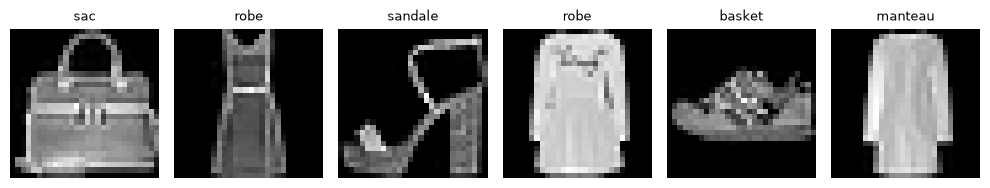

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, label in zip(axes, X_train, y_train):
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Écriture n°1 — Keras (le style déclaratif)

Lis d'abord, questions ensuite. Trois moments : **décrire** le réseau,
**configurer** l'apprentissage (`compile`), **lancer** (`fit`). La boucle
d'entraînement existe, mais Keras l'écrit pour toi.


In [3]:
keras.utils.set_random_seed(42)

modele = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),                          # 28x28 -> 784
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),    # 10 classes
])

modele.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

modele.fit(X_train, y_train, epochs=3, batch_size=64,
           validation_split=0.1, verbose=2)

perte, acc = modele.evaluate(X_test, y_test, verbose=0)
print(f"accuracy test : {acc:.3f}")

modele.save("modele_keras.keras")

Epoch 1/3


85/85 - 0s - 5ms/step - accuracy: 0.6881 - loss: 0.9426 - val_accuracy: 0.7567 - val_loss: 0.6701


Epoch 2/3


85/85 - 0s - 1ms/step - accuracy: 0.7900 - loss: 0.6000 - val_accuracy: 0.7650 - val_loss: 0.6029


Epoch 3/3


85/85 - 0s - 1ms/step - accuracy: 0.8130 - loss: 0.5289 - val_accuracy: 0.7933 - val_loss: 0.5446


accuracy test : 0.809


### 🎯 Questions d'observation (version Keras)

1. Où est défini le **learning rate** ? Et le nombre d'**epochs** ?
2. Où est la boucle d'entraînement ? (Réponse piège : nulle part — `fit()`
   la contient.)
3. Quel **fichier** sort de cette cellule, avec quelle extension ?
4. `validation_split=0.1` : quel geste du parcours reconnais-tu ?


## 3. Écriture n°2 — PyTorch (le style explicite)

**Le même réseau, le même entraînement** — mais tout ce que Keras cachait est
maintenant visible : la boucle sur les epochs, la boucle sur les lots, le
gradient remis à zéro, la rétropropagation, le pas d'optimisation. C'est le
style que tu as croisé en M4-B2.


In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=64, shuffle=True)

modele_pt = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),   # pas de softmax ici : CrossEntropyLoss l'intègre
)
critere = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(modele_pt.parameters(), lr=1e-3)
print(modele_pt)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
for epoch in range(3):                        # la boucle qu'on ne voyait pas
    modele_pt.train()
    perte_totale = 0.0
    for lot_X, lot_y in train_loader:         # ... et celle sur les lots
        optimiseur.zero_grad()
        sorties = modele_pt(lot_X)
        perte = critere(sorties, lot_y)
        perte.backward()                      # rétropropagation
        optimiseur.step()                     # un pas d'optimisation
        perte_totale += perte.item()
    print(f"epoch {epoch + 1} — perte moyenne : "
          f"{perte_totale / len(train_loader):.4f}")

modele_pt.eval()
with torch.no_grad():
    predictions = modele_pt(X_te).argmax(dim=1)
    acc = (predictions == y_te).float().mean().item()
print(f"accuracy test : {acc:.3f}")

torch.save(modele_pt.state_dict(), "modele_pytorch.pt")

epoch 1 — perte moyenne : 1.0148


epoch 2 — perte moyenne : 0.6206
epoch 3 — perte moyenne : 0.5429
accuracy test : 0.810


### 🎯 Questions d'observation (version PyTorch)

1. Retrouve les **4 mêmes informations** que dans la version Keras :
   learning rate, epochs, architecture, fichier de sortie. Lesquelles ont
   changé de place ?
2. `loss.backward()` puis `optimiseur.step()` : à quoi ces deux lignes
   correspondent-elles dans la version Keras ? (Indice : tu ne les voyais
   pas.)
3. Pourquoi `torch.no_grad()` au moment de l'évaluation ?
4. Les deux accuracies test sont-elles proches ? Est-ce surprenant ?


### Ce que produisent les deux versions

Deux formats de sauvegarde différents — exactement la table
**symptôme → framework** de la fiche, en vrai :


In [6]:
from pathlib import Path

for f in sorted(Path(".").glob("modele_*")):
    print(f"{f.name:22s} {f.stat().st_size / 1024:7.0f} Ko")

modele_keras.keras        1215 Ko
modele_pytorch.pt          400 Ko


## 4. La troisième voie — consommer un modèle pré-entraîné

Les deux versions ci-dessus **entraînent**. Ton geste principal
d'intégrateur, lui, tient en 3 lignes : charger un modèle existant et
l'interroger. Ici, un ViT généraliste (entraîné sur ImageNet, pas sur
Fashion-MNIST) à qui l'on montre une image du jeu de test.


In [7]:
from transformers import pipeline
from PIL import Image

classifieur = pipeline("image-classification",
                       model="google/vit-base-patch16-224")

image = Image.fromarray((X_test[0] * 255).astype("uint8")) \
             .convert("RGB").resize((224, 224))

for pred in classifieur(image)[:3]:
    print(f"{pred['label']:40s} {pred['score']:.2f}")
print("classe réelle Fashion-MNIST :", CLASSES[y_test[0]])

hatchet                                  0.06
Loafer                                   0.05
clog, geta, patten, sabot                0.04
classe réelle Fashion-MNIST : bottine


### 🎯 Ce que cette cellule enseigne (au-delà des 3 lignes)

Le modèle répond dans **son** vocabulaire (les 1 000 classes ImageNet), pas
dans celui de Fashion-MNIST — il propose souvent une classe de chaussure ou
de vêtement plausible, parfois complètement à côté. La leçon d'intégrateur :

- **consommer un modèle = vérifier l'adéquation tâche/domaine d'abord**
  (lire la model card, tester sur SES données) — pas « ça marche en 3
  lignes donc c'est bon » ;
- si le vocabulaire ne colle pas, les options sont celles de M4-B2 :
  zero-shot avec les bonnes étiquettes (CLIP), ou transfer learning (geler
  le backbone, réentraîner la tête sur tes 10 classes) ;
- compare les coûts : 3 lignes et 0 entraînement, contre ~40 lignes et un
  entraînement complet plus haut. C'est l'arbitrage de la grille C4.


## 5. Auto-vérification — sauras-tu reconnaître du code hérité ?

Pour chacun de ces trois extraits (issus de « missions » fictives),
identifie le framework et le style, **avant** d'ouvrir la réponse.

**Extrait A**
```python
history = model.fit(X, y, epochs=50, callbacks=[early_stop])
model.save("churn_v3.h5")
```

**Extrait B**
```python
for batch in loader:
    optimizer.zero_grad()
    out = net(batch.x)
    loss = criterion(out, batch.y)
    loss.backward()
    optimizer.step()
```

**Extrait C**
```python
clf = pipeline("sentiment-analysis",
               model="nlptown/bert-base-multilingual-uncased-sentiment")
print(clf("Livraison rapide, produit conforme."))
```

<details>
<summary>👉 Réponses</summary>

- **A** : Keras — `fit` avec callbacks, sauvegarde `.h5` (l'ancien format,
  très courant dans le legacy ; le format moderne est `.keras`).
- **B** : PyTorch — la boucle explicite avec `zero_grad`/`backward`/`step`.
- **C** : Hugging Face `transformers` — consommation d'un modèle
  pré-entraîné ; le moteur dessous est (probablement) PyTorch, mais tu n'as
  pas eu à le savoir pour l'utiliser. Ton terrain.

</details>

---

## La carte, pour finir

```
   Ton application métier
            │
            ▼
   Hugging Face transformers   ← §4 : 3 lignes, ton geste principal
            │
            ▼
   Keras ────────► PyTorch     ← §2 et §3 : le même moteur conceptuel,
   (déclaratif)    (explicite)    deux niveaux de contrôle
            │
            ▼
   CPU / GPU
```

Relis maintenant la **table symptôme → framework** de
`fiche_frameworks_deep_learning.md` : chaque ligne devrait te sembler
évidente — tu viens de toutes les voir en situation.
